# 9.2.1 构造保持目标分布的采样链

## 学习目标与先修知识

推导接受比与提议修正，实现可重放的链并核对详细平衡（detailed balance）。

先修：9.1的目标密度，第5.4章转移矩阵（transition matrix）、平稳分布（distribution）与收敛条件。

## 具体问题

无需计算归一化常数，能否构造一条长期访问频率与目标后验（posterior）一致的链？为什么拒绝候选后，还必须把原状态（state）再记一次？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先在两个状态上检查概率（probability）流。目标质量为[1/4,3/4]，总提议换到另一个状态。

In [2]:
P=np.array([[0.,1.],[1/3,2/3]]);pi=np.array([.25,.75])
print("一步后的分布：",pi@P)
print("两方向概率流：",pi[0]*P[0,1],pi[1]*P[1,0])

一步后的分布： [0.25 0.75]
两方向概率流： 0.25 0.25


## 模型假设

连续例使用无量纲（dimensionless）化个体偏差x的等权双高斯目标p(x)=[N(x|−d,1)+N(x|d,1)]/2。两个峰用于观察采样（sampling）链能否探索相隔较远的高密度区域。提议与均匀数独立产生；固定候选题目则直接提供它们以复算。有限状态例目标各项严格正，提议矩阵（matrix）每行和为1；这些条件本身不保证不可约（irreducible）。

## 数学解释与推导

从x提议y的密度为q(y|x)，接受概率取
$$\alpha(x,y)=\min\left(1,\frac{\tilde p(y)q(x|y)}{\tilde p(x)q(y|x)}\right).$$
未归一化密度 $\tilde p$ 的常数在比值中相消。非对称提议时反向/正向提议比不能删掉。对于非对角概率流，
$$p(x)q(y|x)\alpha(x,y)=\min\{p(x)q(y|x),p(y)q(x|y)\},$$
右侧交换x,y不变，得到详细平衡（detailed balance）。把未接受的概率放到自环，总概率守恒；详细平衡进一步推出p是平稳分布。

这不是从任何初态出发都会收敛的完整证明。有限状态还需不可约和非周期（aperiodic）等条件；连续状态的相应条件更细，留作拓展。P=I虽满足详细平衡，却从不离开起点。

实际计算用 $\log\alpha=\min(0,\log\tilde p(y)-\log\tilde p(x)+\log q(x|y)-\log q(y|x))$。取0≤u<1，若u=0或logu<logα则接受。拒绝后x保持，但仍记录一次：删去重复点会删去停留时间，改变经验分布。

对称随机游走（random walk）y=x+sξ、ξ~N(0,1)可以约去提议比。小s容易接受但移动慢，大s可能频繁拒绝；两者都可能减少有限预算下的信息。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)


def mixture_logpdf(value,separation):
    return logsumexp([normal_logpdf(value,-separation,1),normal_logpdf(value,separation,1)])-math.log(2)


def mh_steps(initial,candidates,log_reverse_over_forward,uniforms,separation):
    state=initial;path=[state];accepted=[]
    for candidate,ratio,u in zip(candidates,log_reverse_over_forward,uniforms):
        log_alpha=min(0.,mixture_logpdf(candidate,separation)-mixture_logpdf(state,separation)+ratio)
        take=(u==0 or math.log(u)<log_alpha)
        if take:state=candidate
        accepted.append(take);path.append(state)
    return path,accepted


def finite_mh(target,proposal):
    n=len(target);P=[[0.]*n for _ in target]
    for i in range(n):
        for j in range(n):
            if j!=i and proposal[i][j]>0:
                P[i][j]=proposal[i][j]*min(1.,target[j]*proposal[j][i]/(target[i]*proposal[i][j]))
        P[i][i]=1-sum(P[i])
    return P


def random_walk(initial,increments,uniforms,separation):
    state=initial;path=[state];accepted=[]
    for increment,u in zip(increments,uniforms):
        candidate=state+increment
        take=u==0 or math.log(u)<min(0.,mixture_logpdf(candidate,separation)-mixture_logpdf(state,separation))
        if take:state=candidate
        path.append(state);accepted.append(take)
    return path,accepted

## 对照实验

展示相同固定候选序列的重放，以及同一随机流下不同步幅的轨迹（trajectory）。目标d=0时是标准高斯，已有精确参照。随机流种子901，完整长度400步，图中的短链只展示接受机制。

| 步骤 | 状态 | 是否接受 |
| --- | --- | --- |
| 0 | 1 | 1 |
| 1 | 1 | 0 |
| 2 | -1 | 1 |

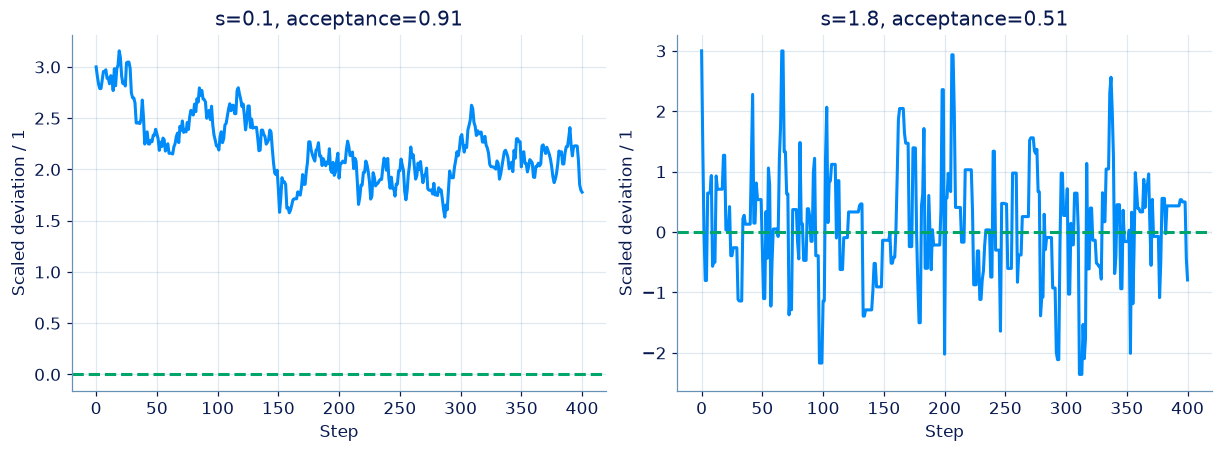

In [4]:
path,accepted=mh_steps(0,[1,4,-1],[0,0,0],[.2,.9,.3],0)
display(Markdown(show_table(['步骤','状态','是否接受'],[(i,path[i+1],accepted[i]) for i in range(3)])))
rng=np.random.default_rng(901);base=rng.normal(size=400);uniforms=rng.random(400)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,scale in zip(axes,[.1,1.8]):
    states,takes=random_walk(3,(scale*base).tolist(),uniforms.tolist(),0)
    ax.plot(states);ax.axhline(0,color=GREEN,linestyle='--');ax.set(xlabel='Step',ylabel='Scaled deviation / 1',title=f's={scale}, acceptance={np.mean(takes):.2f}')
plt.show()

## 结果解释

固定序列得到[0,1,1,−1]，其中第二步拒绝并保留1。两个步幅的短轨迹显示，较高接受率可能伴随较小有效移动。绿色线是已知目标均值，不表示每条有限链都必须在每个时间窗围绕它对称。此处建立算法，下一节才系统比较预热、多链和相关性。

### 独立核对

直接核对有限状态概率流、行和与平稳分布，再检查拒绝、非对称提议修正、空步骤与均匀数为0的边界。

In [5]:
pi=np.array([.2,.3,.5]);Q=[[.2,.5,.3],[.1,.5,.4],[.4,.2,.4]]
P=np.array(finite_mh(pi.tolist(),Q));np.testing.assert_allclose(P.sum(axis=1),1)
flow=pi[:,None]*P;np.testing.assert_allclose(flow,flow.T);np.testing.assert_allclose(pi@P,pi)
assert path==[0,1,1,-1] and accepted==[True,False,True]
assert mh_steps(0,[1],[-2],[.5],0)==([0,0],[False])
assert mh_steps(2,[],[],[],3)==([2],[])
assert mh_steps(0,[100],[0],[0],0)[1]==[True]
print('独立概率流与接受/拒绝边界通过。')

独立概率流与接受/拒绝边界通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-02-马尔可夫链采样与诊断/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：重放一次次接受与拒绝

目标是等权双高斯混合。用题给候选点、提议比与均匀数重放MH链；不得再随机抽样。

**函数与代码模板**

```python
def solve(
    initial: float,
    candidates: list[float],
    log_reverse_over_forward: list[float],
    uniforms: list[float],
    separation: float,
) -> tuple[list[float], list[bool]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 初始链状态（state）。 | 1 |
| `candidates` | `list[float]` | 依次给定的候选点，拒绝后下一候选仍按本列表读取。 | 1 |
| `log_reverse_over_forward` | `list[float]` | 每一步log q(当前&#124;候选)−log q(候选&#124;当前)。 | 1 |
| `uniforms` | `list[float]` | 固定均匀数；0≤u<1。 | 1 |
| `separation` | `float` | 等权N(−d,1)、N(d,1)目标中的d。 | 1 |

**返回值**

按以下顺序返回元组：(states, accepted)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初值（initial condition）和每次接受/拒绝后状态。 | 1 |
| `accepted` | `list[bool]` | 按步骤返回是否接受。 | 不适用 |

**计算规则**

logα=min(0,logp(candidate)−logp(current)+log_reverse_over_forward[i])。u=0或logu<logα即接受，否则保持当前值。d=0退化成N(0,1)。

**约束与边界**

- 三组步骤列表等长0—100；数值绝对值≤100；0≤d≤5；均匀数在[0,1)。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 初始链状态（state）。 | 0 | 1 |
| candidates | 依次给定的候选点，拒绝后下一候选仍按本列表读取。 | [1.0, 4.0, -1.0] | 1 |
| log_reverse_over_forward | 每一步log q(当前|候选)−log q(候选|当前)。 | [0.0, 0.0, 0.0] | 1 |
| uniforms | 固定均匀数；0≤u<1。 | [0.2, 0.9, 0.3] | 1 |
| separation | 等权N(−d,1)、N(d,1)目标中的d。 | 0 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 0.0
candidates = [1.0, 4.0, -1.0]
log_reverse_over_forward = [0.0, 0.0, 0.0]
uniforms = [0.2, 0.9, 0.3]
separation = 0.0

result = solve(initial, candidates, log_reverse_over_forward, uniforms, separation)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初值（initial condition）和每次接受/拒绝后状态。 | [0.0, 1.0, 1.0, -1.0] | 1 |
| accepted | 按步骤返回是否接受。 | [True, False, True] | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 1.0, 1.0, -1.0],
                   [True, False, True])
```

**样例解释**

第一步exp(−1/2)>.2故接受1；第二步概率（probability）exp(−7.5)<.9故保持1；第三步到−1密度相同故接受。轨迹（trajectory）为[0,1,1,−1]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：重放一次次接受与拒绝](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-mh-replay)

### 第 2 题 · Python 计算题：构造有限状态转移核

正目标质量π与行随机提议矩阵（matrix）Q已给定。对非对角项作MH接受修正，将拒绝质量留在对角。

**函数与代码模板**

```python
def solve(
    target: list[float],
    proposal: list[list[float]],
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `target` | `list[float]` | 和为1的正目标概率（probability）。 | 1 |
| `proposal` | `list[list[float]]` | 每行和为1的非负提议概率矩阵。 | 1 |

**返回值**

直接返回 transition（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | MH后的行随机转移矩阵（transition matrix）。 | 1 |

**计算规则**

i≠j且Qij>0时Pij=min(Qij,πj Qji/πi)；Qij=0时Pij=0；Pii=1−sum(j≠i)Pij。

**约束与边界**

- 2—4状态（state）；πi≥0.01；不要求Q对称；允许单向提议和对角概率。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| target | 和为1的正目标概率（probability）。 | [0.25, 0.75] | 1 |
| proposal | 每行和为1的非负提议概率矩阵。 | [[0.0, 1.0], [1.0, 0.0]] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
target = [0.25, 0.75]
proposal = [[0.0, 1.0], [1.0, 0.0]]

result = solve(target, proposal)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| transition | MH后的行随机转移矩阵（transition matrix）。 | [[0.0, 1.0], [0.3333333333333333, 0.6666666666666667]] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.0, 1.0],
                   [0.3333333333333333, 0.6666666666666667]]
```

**样例解释**

第一行必到第二状态；第二行以1/3到第一状态、2/3留下。两方向概率流都是0.25。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：构造有限状态转移核](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-finite-kernel)

### 第 3 题 · 单项选择题：提议方向不要写反

非对称提议q(y|x)的MH接受概率（probability）中，提议修正是哪一个？

- **A.** q(y|x)/q(x|y)。
- **B.** q(x|y)/q(y|x)。
- **C.** 无论是否对称都能约掉。
- **D.** 只要目标已归一化就不需要它。

[作答：提议方向不要写反](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-proposal-ratio)

### 第 4 题 · 多项选择题：保持目标就一定收敛吗

P=I满足任意π的详细平衡（detailed balance）。它能否从任意初态探索给定π？

- **A.** 能，因为已经详细平衡。
- **B.** 不能，链一直保持初态。
- **C.** 还需讨论不可约（irreducible）性与周期性等条件。
- **D.** 有限状态（state）不可约且非周期（aperiodic）时，才有熟悉的唯一平稳及长期收敛结论。

[作答：保持目标就一定收敛吗](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-stationary-vs-convergence)

### 第 5 题 · 单项选择题：拒绝时要不要记录

MH模拟总共1000步，其中拒绝600次。为了计算后验（posterior）矩应怎样保存？

- **A.** 只保存400个接受后的点并等权平均。
- **B.** 保存每一步状态（state），拒绝时重复当前点。
- **C.** 拒绝意味着数值失败，必须删除。
- **D.** 重复状态的停留时间与目标质量无关。

[作答：拒绝时要不要记录](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-rejections)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。